# Studies: train + compare in one call

`compare` assumes you already have trained models. `Study` closes the loop: you
give it a `train_fn(seed) -> checkpoint_path` per method and the seeds, and it
runs the whole multi-seed training sweep **and** the comparison in a single
call, returning the same `BenchmarkResult`.

In [ ]:
from __future__ import annotations

import tempfile
from pathlib import Path

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from mushin import Study

Tiny synthetic 3-class data again (no downloads).

In [ ]:
NUM_CLASSES = 3


def make_loader(n: int = 256, seed: int = 0) -> DataLoader:
    g = torch.Generator().manual_seed(seed)
    y = torch.randint(0, NUM_CLASSES, (n,), generator=g)
    x = torch.randn(n, 1, 8, 8, generator=g) + y.view(n, 1, 1, 1)
    return DataLoader(TensorDataset(x, y), batch_size=64)


train_loader = make_loader(seed=0)
test_loader = make_loader(n=128, seed=99)

A `train_fn` per method: train, save a checkpoint, return its path.

In [ ]:
def make_cnn():
    return nn.Sequential(
        nn.Conv2d(1, 8, 3, padding=1), nn.ReLU(),
        nn.AdaptiveAvgPool2d(4), nn.Flatten(),
        nn.Linear(8 * 4 * 4, NUM_CLASSES),
    )


def make_mlp():
    return nn.Sequential(
        nn.Flatten(), nn.Linear(8 * 8, 32), nn.ReLU(), nn.Linear(32, NUM_CLASSES)
    )


ckpt_dir = Path(tempfile.mkdtemp())


def make_train_fn(name, factory):
    def train_fn(seed: int) -> str:
        torch.manual_seed(seed)
        model = factory()
        opt = torch.optim.Adam(model.parameters(), lr=1e-2)
        model.train()
        for _ in range(3):
            for x, y in train_loader:
                opt.zero_grad()
                nn.functional.cross_entropy(model(x), y).backward()
                opt.step()
        path = ckpt_dir / f"{name}_seed{seed}.pt"
        torch.save(model.eval(), path)
        return str(path)

    return train_fn

Hand the methods, loader, and seeds to `Study` — it does the rest.

In [ ]:
study = Study(
    methods={
        "cnn": make_train_fn("cnn", make_cnn),
        "mlp": make_train_fn("mlp", make_mlp),
    },
    load_fn=lambda p: torch.load(p, weights_only=False),
    seeds=[0, 1, 2],
    data=test_loader,
    num_classes=NUM_CLASSES,
    test="welch",
    working_dir=tempfile.mkdtemp(),
)
result = study.run()
result.summary()

[2026-07-14 20:36:06,553][HYDRA] Launching 6 jobs locally


[2026-07-14 20:36:06,553][HYDRA] 	#0 : +method_index=0 +seed=0


[2026-07-14 20:36:06,655][HYDRA] 	#1 : +method_index=0 +seed=1


[2026-07-14 20:36:06,736][HYDRA] 	#2 : +method_index=0 +seed=2


/Users/josuemartinez/code/mushin/.venv/lib/python3.10/site-packages/hydra/_internal/core_plugins/basic_launcher.py:74: UserWarning: Future Hydra versions will no longer change working directory at job runtime by default.
See https://hydra.cc/docs/1.2/upgrades/1.1_to_1.2/changes_to_job_working_dir/ for more information.
  ret = run_job(
/Users/josuemartinez/code/mushin/.venv/lib/python3.10/site-packages/hydra/_internal/core_plugins/basic_launcher.py:74: UserWarning: Future Hydra versions will no longer change working directory at job runtime by default.
See https://hydra.cc/docs/1.2/upgrades/1.1_to_1.2/changes_to_job_working_dir/ for more information.
  ret = run_job(
/Users/josuemartinez/code/mushin/.venv/lib/python3.10/site-packages/hydra/_internal/core_plugins/basic_launcher.py:74: UserWarning: Future Hydra versions will no longer change working directory at job runtime by default.
See https://hydra.cc/docs/1.2/upgrades/1.1_to_1.2/changes_to_job_working_dir/ for more information.
  r

[2026-07-14 20:36:06,818][HYDRA] 	#3 : +method_index=1 +seed=0


[2026-07-14 20:36:06,885][HYDRA] 	#4 : +method_index=1 +seed=1


[2026-07-14 20:36:06,953][HYDRA] 	#5 : +method_index=1 +seed=2


/Users/josuemartinez/code/mushin/.venv/lib/python3.10/site-packages/hydra/_internal/core_plugins/basic_launcher.py:74: UserWarning: Future Hydra versions will no longer change working directory at job runtime by default.
See https://hydra.cc/docs/1.2/upgrades/1.1_to_1.2/changes_to_job_working_dir/ for more information.
  ret = run_job(
/Users/josuemartinez/code/mushin/.venv/lib/python3.10/site-packages/hydra/_internal/core_plugins/basic_launcher.py:74: UserWarning: Future Hydra versions will no longer change working directory at job runtime by default.
See https://hydra.cc/docs/1.2/upgrades/1.1_to_1.2/changes_to_job_working_dir/ for more information.
  ret = run_job(
/Users/josuemartinez/code/mushin/.venv/lib/python3.10/site-packages/hydra/_internal/core_plugins/basic_launcher.py:74: UserWarning: Future Hydra versions will no longer change working directory at job runtime by default.
See https://hydra.cc/docs/1.2/upgrades/1.1_to_1.2/changes_to_job_working_dir/ for more information.
  r

,method,metric,mean,ci_low,ci_high,significant_vs_ref
0,cnn,accuracy,0.932292,0.657602,1.206981,
1,cnn,f1,0.926364,0.627760,1.224969,
2,cnn,precision,0.948839,0.749432,1.148247,
3,cnn,recall,0.938534,0.689171,1.187898,
4,cnn,auroc,1.000000,1.000000,1.000000,
5,cnn,ece,0.213770,0.134301,0.293239,
6,mlp,accuracy,0.697917,0.574664,0.821170,*
7,mlp,f1,0.674078,0.519165,0.828991,*
8,mlp,precision,0.733587,0.606323,0.860850,*
9,mlp,recall,0.726655,0.615083,0.838226,


Same `BenchmarkResult` as `compare` — plot the per-method accuracy with CIs.

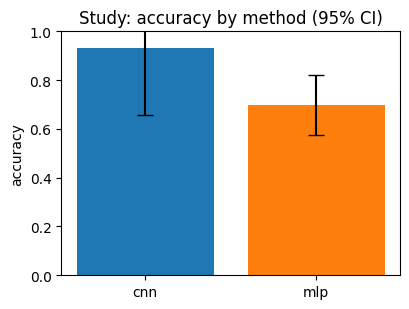

In [ ]:
import matplotlib.pyplot as plt

acc = result.summary().query("metric == 'accuracy'")
fig, ax = plt.subplots(figsize=(4.2, 3.2))
lo = (acc["mean"] - acc["ci_low"]).values
hi = (acc["ci_high"] - acc["mean"]).values
ax.bar(acc["method"], acc["mean"], yerr=[lo, hi], capsize=6,
       color=["tab:blue", "tab:orange"])
ax.set_ylabel("accuracy")
ax.set_ylim(0, 1)
ax.set_title("Study: accuracy by method (95% CI)")
fig.tight_layout()
plt.show()

**See also**

- [Studies guide](../guides/study.md) — resilience options, provenance, and
  wiring `Study` to real training loops.
- [Notebook 02](02_compare_and_batteries.ipynb) — the `compare`-only flow.